In [20]:
import numpy as np
from pathlib import Path
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv

In [21]:
np.random.seed(123)

In [22]:
# Ruta al dataset
# Lo tenemos en la misma carpeta que el notebook
dataset_path = Path("roads")
sat_path = dataset_path / "sat" # Carpeta con las imagenes por satelite
gt_path = dataset_path / "gt" # Carpeta con las carreteras marcadas

# Cargar las imágenes
# Las ordenamos para que cada que cada imagen de la carpeta sat este en la misma posicion que en la carpeta gt (tienen el mismo nombre)
sat_files = sorted(sat_path.glob("*.tif*")) # Leer todas las de la carpeta a la vez
gt_files = sorted(gt_path.glob("*.tif*"))

# Leer imágenes y máscaras
images = []
masks = []

for sat_file, gt_file in zip(sat_files, gt_files):
    # Cargar imagen del satelite
    img = io.imread(sat_file)
    images.append(img)
    
    # Cargar máscara y binarizar
    mask = io.imread(gt_file)
    mask = (mask > 128).astype(np.uint8) # Lo tenemos que poner en 0 y 1 porque ahora tiene como valores 0 y 255
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print(f"Shape imágenes: {images.shape}")
print(f"Shape máscaras: {masks.shape}")

Shape imágenes: (20, 1500, 1500, 3)
Shape máscaras: (20, 1500, 1500)


In [23]:
# Dividir aleatoriamente
n_total = len(images)
indices = np.random.permutation(n_total) # devuelve una secuencia desordenada de numeros del 0 a n_total - 1

# Dividir indices
test_indices = indices[:2] # 2 primeras para test
val_indices = indices[2:4] # 2 siguientes para val
train_indices = indices[4:] # resto para train

X_test = images[test_indices]
y_test = masks[test_indices]

X_val = images[val_indices]
y_val = masks[val_indices]

X_train = images[train_indices]
y_train = masks[train_indices]

print(f"Train: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test: {len(X_test)} imágenes")

Train: 16 imágenes
Validación: 2 imágenes
Test: 2 imágenes


In [24]:
def normalize_images(images):
    """Normaliza imágenes al rango [0, 1]"""
    return images.astype(np.float32) / 255.0

In [25]:
def flatten_data(X, y):
    """Aplana imágenes para usar con clasificadores pixel-wise"""
    X_flat = X.reshape(-1, X.shape[-1])
    y_flat = y.reshape(-1)
    return X_flat, y_flat

In [26]:
def undersample(image, mask):
    """Balancea datos ya aplanados para tener igual cantidad de cada clase"""
    # Índices de cada clase
    road_idx = np.where(mask == 1)[0]
    bg_idx = np.where(mask == 0)[0]
    
    # Mantener todos los píxeles de carretera
    # Reducir fondo al mismo número
    n_road = len(road_idx)
    bg_sampled = np.random.choice(bg_idx, n_road, replace=False)
    
    # Combinar y mezclar
    selected = np.concatenate([road_idx, bg_sampled])
    np.random.shuffle(selected)
    
    return image[selected], mask[selected]

# NOTA: AL HACER EL UNDERSAMPLING NOS QUEDAMOS SOLO CON ALGUNAS MUESTRAS ASI QUE PERDEMOS QUE PIXELES ESTAN AL LADO DE OTROS
# tenemos que características antes del undersampling (con vecindad) cuando vayamos a hacerlo

In [27]:
# Normalizar todos los conjuntos
X_train_norm = normalize_images(X_train)
X_val_norm = normalize_images(X_val)
X_test_norm = normalize_images(X_test)

print(f"Rango sin normalizar train: {X_train.min():.2f}-{X_train.max():.2f}")
print(f"Rango normalizado train: {X_train_norm.min():.2f}-{X_train_norm.max():.2f}")

# Aplanar todos los conjuntos
X_train_flat, y_train_flat = flatten_data(X_train_norm, y_train)
X_val_flat, y_val_flat = flatten_data(X_val_norm, y_val)
X_test_flat, y_test_flat = flatten_data(X_test_norm, y_test)

print(f"\nDatos aplanados (inputs ; target):")
print(f"  Train: {X_train_flat.shape} ; {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

# Aplicar undersampling solo a train
X_train_balanced, y_train_balanced = undersample(X_train_flat, y_train_flat)

print(f"\nDatos después de undersampling (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} ; {y_train_balanced.shape}")

print(f"\nDatos preparados finales (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} → {y_train_balanced.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

Rango sin normalizar train: 0.00-255.00
Rango normalizado train: 0.00-1.00

Datos aplanados (inputs ; target):
  Train: (36000000, 3) ; (36000000,)
  Val:   (4500000, 3) ; (4500000,)
  Test:  (4500000, 3) ; (4500000,)

Datos después de undersampling (inputs ; target):
  Train: (2529114, 3) ; (2529114,)

Datos preparados finales (inputs ; target):
  Train: (2529114, 3) → (2529114,)
  Val:   (4500000, 3) ; (4500000,)
  Test:  (4500000, 3) ; (4500000,)



=== ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    2.6s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    3.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Modelo entrenado

=== EVALUACIÓN ===


[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.5s finished


Validación:
  Accuracy:  0.8244
  Precision: 0.2314
  Recall:    0.7799
  F1-Score:  0.3570


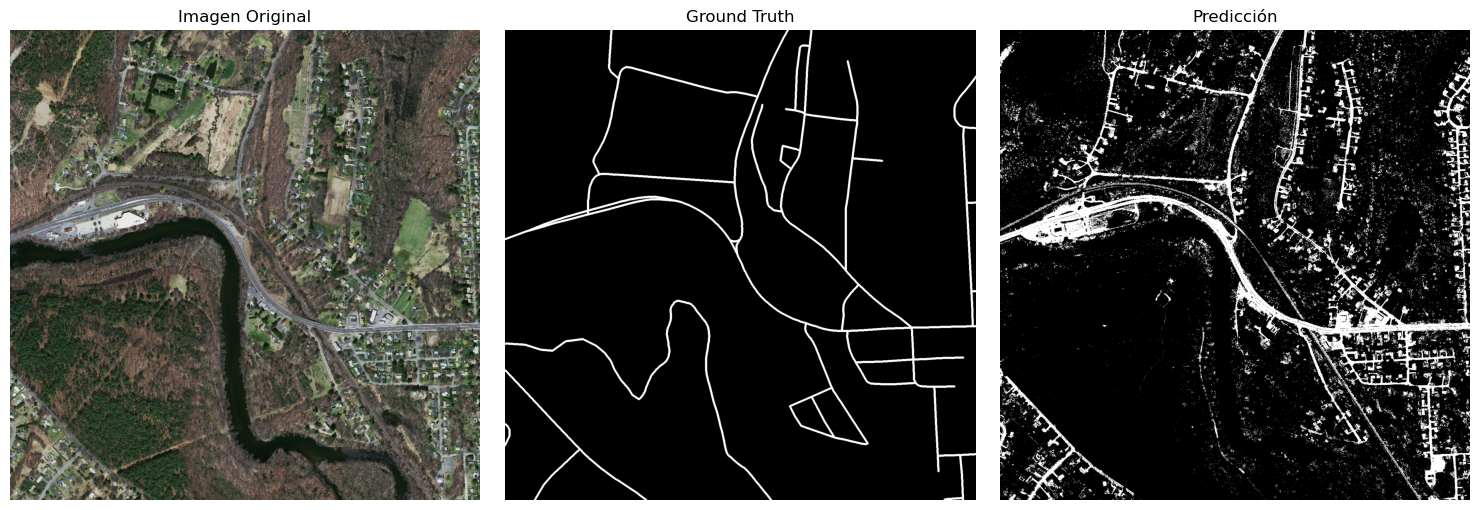

In [28]:
print("\n=== ENTRENAMIENTO ===")

print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")

model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model.fit(X_train_balanced, y_train_balanced)

print("Modelo entrenado")

print("\n=== EVALUACIÓN ===")

# Evaluar en validación
y_val_pred = model.predict(X_val_flat)

acc = accuracy_score(y_val_flat, y_val_pred)
prec = precision_score(y_val_flat, y_val_pred)
rec = recall_score(y_val_flat, y_val_pred)
f1 = f1_score(y_val_flat, y_val_pred)

print(f"Validación:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Visualizar predicción en una imagen de validación
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_val[0])
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(y_val[0], cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis('off')

axes[2].imshow(y_val_pred_img[0], cmap='gray')
axes[2].set_title("Predicción")
axes[2].axis('off')

plt.tight_layout()
plt.show()

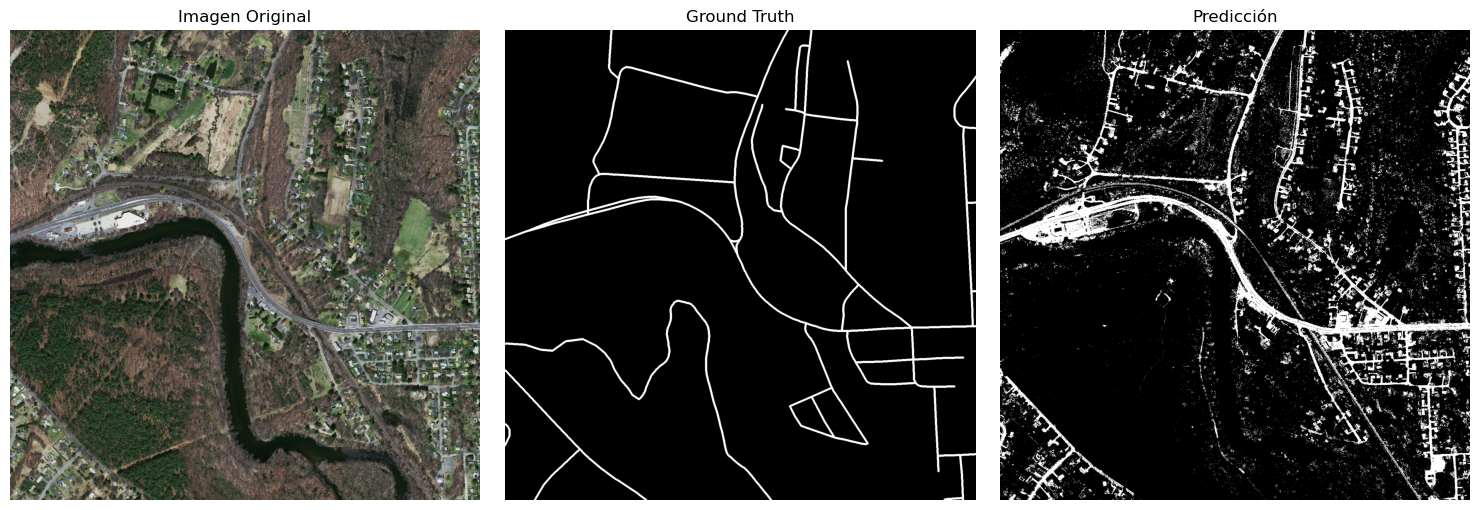

In [29]:
# 5. Visualizar predicción en una imagen de validación
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_val[0])
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(y_val[0], cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis('off')

axes[2].imshow(y_val_pred_img[0], cmap='gray')
axes[2].set_title("Predicción")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [30]:
# NOTA: ESTA FUNCION HABRA QUE CAMBIARLA PORQUE LUEGO VAMOS A EXTRAER MAS FEATURES TMB
# PODEMOS HACER QUE LAS EXTRAIGA Y LAS DEVUELVA Y YA ESTA
# Y LUEGO OTRA FUNCION QUE TE LAS JUNTE TODAS CON STACK PARA PODER REUTILIZARLA

def extract_color_features(images):
    """Extrae características de color para todas las imágenes"""
    from skimage.color import rgb2hsv
    
    all_features = []
    
    for img in images:
        # Normalizar si no está normalizado
        if img.max() > 1.0:
            img_norm = img.astype(np.float32) / 255.0
        else:
            img_norm = img.astype(np.float32)
        
        feature_maps = []
        
        # RGB original
        feature_maps.append(img_norm[:,:,0])
        feature_maps.append(img_norm[:,:,1])
        feature_maps.append(img_norm[:,:,2])
        
        # HSV (saturación muy útil para carreteras)
        hsv = rgb2hsv(img_norm)
        feature_maps.append(hsv[:,:,0])
        feature_maps.append(hsv[:,:,1])
        feature_maps.append(hsv[:,:,2])
        
        # ESTO ME LO HIZO EL AMIGO PERO NO LO HE USADO AUN
        # Intensidad promedio
        intensity = np.mean(img_norm, axis=2)
        feature_maps.append(intensity)
        
        # Índice de grisura (carreteras son grises/negras)
        gray_idx = (np.abs(img_norm[:,:,0] - img_norm[:,:,1]) + 
                    np.abs(img_norm[:,:,1] - img_norm[:,:,2]) + 
                    np.abs(img_norm[:,:,0] - img_norm[:,:,2]))
        feature_maps.append(gray_idx)
        
        # Apilar todas las características en la tercera dimensión
        features = np.dstack(feature_maps)
        all_features.append(features)
    
    return np.array(all_features)

In [31]:
# Normalizar todos los conjuntos
X_train_norm = normalize_images(X_train)
X_val_norm = normalize_images(X_val)
X_test_norm = normalize_images(X_test)

print(f"Rango sin normalizar train: {X_train.min():.2f}-{X_train.max():.2f}")
print(f"Rango normalizado train: {X_train_norm.min():.2f}-{X_train_norm.max():.2f}")

X_train_norm = extract_color_features(X_train_norm)
X_val_norm = extract_color_features(X_val_norm)
X_test_norm = extract_color_features(X_test_norm)

# Aplanar todos los conjuntos
X_train_flat, y_train_flat = flatten_data(X_train_norm, y_train)
X_val_flat, y_val_flat = flatten_data(X_val_norm, y_val)
X_test_flat, y_test_flat = flatten_data(X_test_norm, y_test)

print(f"\nDatos aplanados (inputs ; target):")
print(f"  Train: {X_train_flat.shape} ; {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

# Aplicar undersampling solo a train
X_train_balanced, y_train_balanced = undersample(X_train_flat, y_train_flat)

print(f"\nDatos después de undersampling (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} ; {y_train_balanced.shape}")

print(f"\nDatos preparados finales (inputs ; target):")
print(f"  Train: {X_train_balanced.shape} → {y_train_balanced.shape}")
print(f"  Val:   {X_val_flat.shape} ; {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape} ; {y_test_flat.shape}")

Rango sin normalizar train: 0.00-255.00
Rango normalizado train: 0.00-1.00

Datos aplanados (inputs ; target):
  Train: (36000000, 8) ; (36000000,)
  Val:   (4500000, 8) ; (4500000,)
  Test:  (4500000, 8) ; (4500000,)

Datos después de undersampling (inputs ; target):
  Train: (2529114, 8) ; (2529114,)

Datos preparados finales (inputs ; target):
  Train: (2529114, 8) → (2529114,)
  Val:   (4500000, 8) ; (4500000,)
  Test:  (4500000, 8) ; (4500000,)



=== ENTRENAMIENTO ===
Entrenando con 2529114 píxeles balanceados...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    4.0s remaining:    2.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    5.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Modelo entrenado

=== EVALUACIÓN ===


[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.3s remaining:    0.2s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.4s finished


Validación:
  Accuracy:  0.8244
  Precision: 0.2324
  Recall:    0.7863
  F1-Score:  0.3588


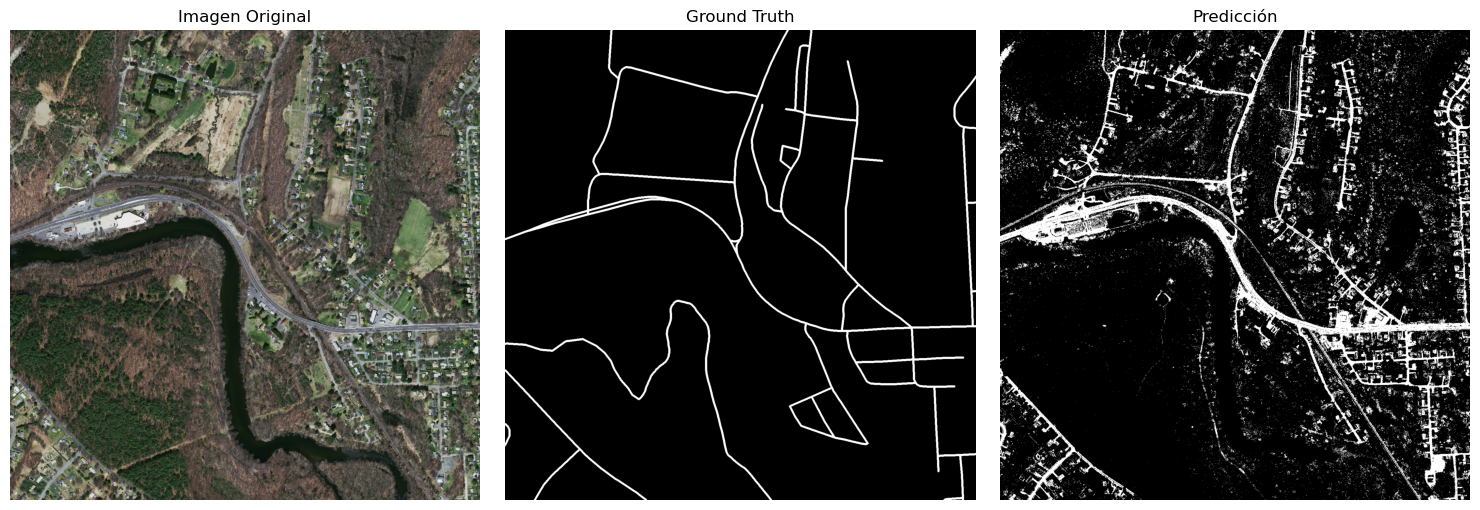

In [32]:
print("\n=== ENTRENAMIENTO ===")

print(f"Entrenando con {len(X_train_balanced)} píxeles balanceados...")

model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model.fit(X_train_balanced, y_train_balanced)

print("Modelo entrenado")

print("\n=== EVALUACIÓN ===")

# Evaluar en validación
y_val_pred = model.predict(X_val_flat)

acc = accuracy_score(y_val_flat, y_val_pred)
prec = precision_score(y_val_flat, y_val_pred)
rec = recall_score(y_val_flat, y_val_pred)
f1 = f1_score(y_val_flat, y_val_pred)

print(f"Validación:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Visualizar predicción en una imagen de validación
y_val_pred_img = y_val_pred.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(X_val[0])
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(y_val[0], cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis('off')

axes[2].imshow(y_val_pred_img[0], cmap='gray')
axes[2].set_title("Predicción")
axes[2].axis('off')

plt.tight_layout()
plt.show()